In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [2]:
B04_PATH = "../data/raw/S2A_MSIL2A_20170210T045931_N0500_R119_T44PKT_20230916T013342.SAFE/GRANULE/L2A_T44PKT_A008553_20170210T051531/IMG_DATA/R10m/T44PKT_20170210T045931_B04_10m.jp2"

B08_PATH = "../data/raw/S2A_MSIL2A_20170210T045931_N0500_R119_T44PKT_20230916T013342.SAFE/GRANULE/L2A_T44PKT_A008553_20170210T051531/IMG_DATA/R10m/T44PKT_20170210T045931_B08_10m.jp2"

In [3]:
with rasterio.open(B04_PATH) as src:
    red = src.read(1)
    profile = src.profile

with rasterio.open(B08_PATH) as src:
    nir = src.read(1)

print("Red shape:", red.shape)
print("NIR shape:", nir.shape)

Red shape: (10980, 10980)
NIR shape: (10980, 10980)


In [7]:
print("Red dtype:", red.dtype)
print("NIR dtype:", nir.dtype)

print("Red min/max:", red.min(), red.max())
print("NIR min/max:", nir.min(), nir.max())

print("Red NoData:", np.sum(red == 0))
print("NIR NoData:", np.sum(nir == 0))


Red dtype: uint16
NIR dtype: uint16
Red min/max: 0 12680
NIR min/max: 0 13112
Red NoData: 87598381
NIR NoData: 87598381


In [8]:
# ndvi calculation 
# Convert to float for NDVI calculation
red_float = red.astype(np.float32)
nir_float = nir.astype(np.float32)

# Create mask for valid pixels
valid = (red > 0) & (nir > 0)

# Initialize NDVI with NaN
ndvi = np.full(red.shape, np.nan, dtype=np.float32)

# Calculate NDVI only for valid pixels
ndvi[valid] = (nir_float[valid] - red_float[valid]) / (
    nir_float[valid] + red_float[valid]
)

print("NDVI calculated successfully.")
print("NDVI min:", np.nanmin(ndvi))
print("NDVI max:", np.nanmax(ndvi))
print("NDVI mean:", np.nanmean(ndvi))

NDVI calculated successfully.
NDVI min: -0.8271471
NDVI max: 0.71563876
NDVI mean: 0.29021928


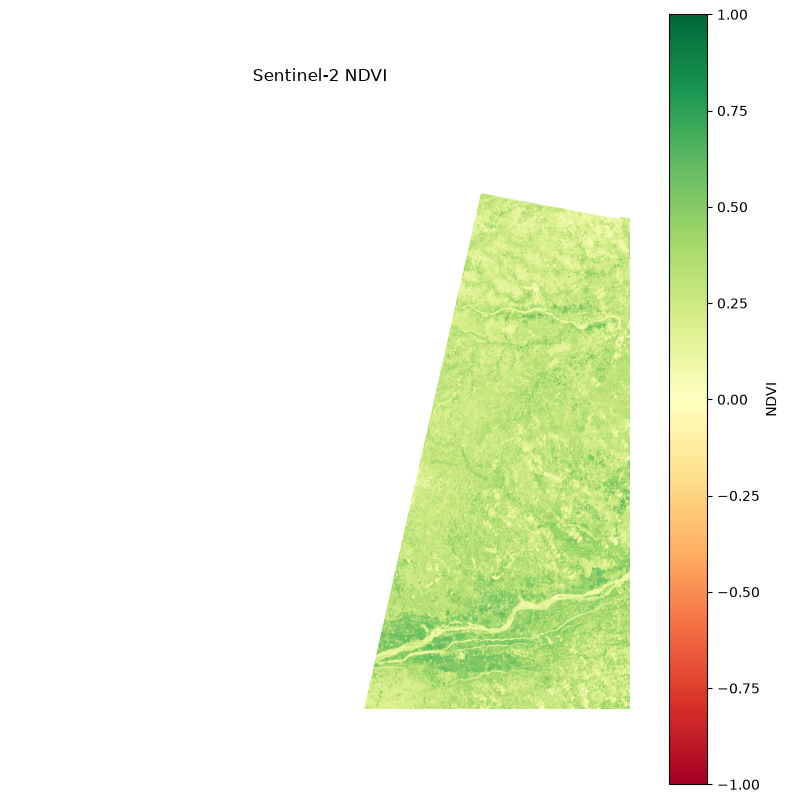

In [9]:
plt.figure(figsize=(10, 10))

plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI")
plt.title("Sentinel-2 NDVI")
plt.axis("off")

plt.show()

In [10]:
# Remove NaN values
valid_ndvi = ndvi[~np.isnan(ndvi)]

ranges = {
    "Very low (< 0)": np.sum(valid_ndvi < 0),
    "Low (0–0.2)": np.sum((valid_ndvi >= 0) & (valid_ndvi < 0.2)),
    "Moderate (0.2–0.4)": np.sum((valid_ndvi >= 0.2) & (valid_ndvi < 0.4)),
    "High (0.4–0.6)": np.sum((valid_ndvi >= 0.4) & (valid_ndvi < 0.6)),
    "Very high (> 0.6)": np.sum(valid_ndvi >= 0.6),
}

total = len(valid_ndvi)

for category, count in ranges.items():
    print(f"{category}: {count:,} pixels ({count / total * 100:.2f}%)")

Very low (< 0): 49,503 pixels (0.15%)
Low (0–0.2): 8,350,080 pixels (25.33%)
Moderate (0.2–0.4): 18,157,403 pixels (55.09%)
High (0.4–0.6): 6,230,034 pixels (18.90%)
Very high (> 0.6): 174,998 pixels (0.53%)


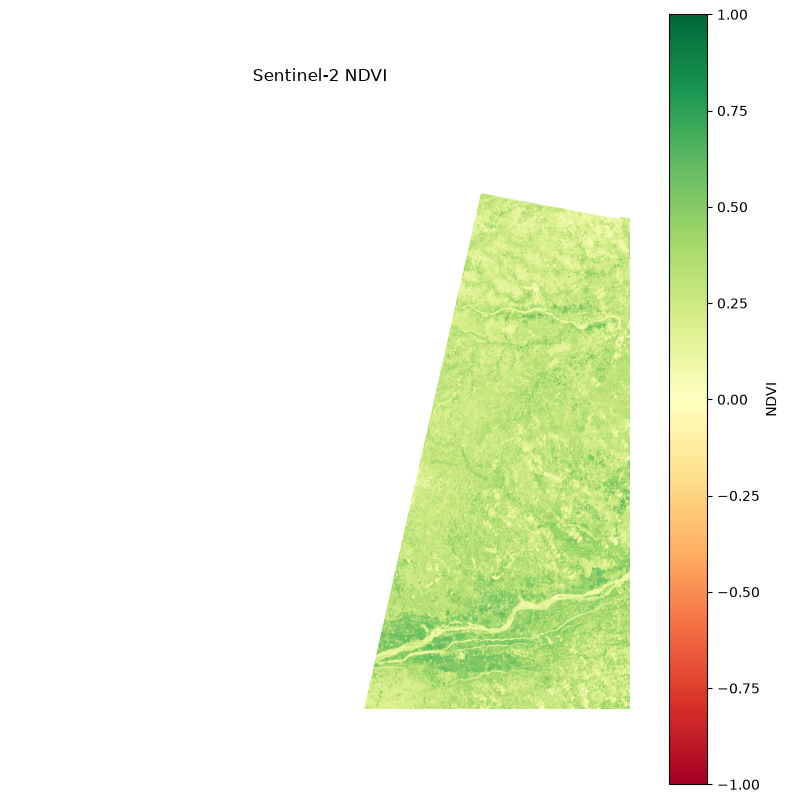

In [11]:
plt.figure(figsize=(10, 10))

plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI")
plt.title("Sentinel-2 NDVI")
plt.axis("off")

plt.show()